# BlackTrace — SHAP Explainability Analysis

This notebook adds explainability and interpretability to the BlackTrace intrusion detection pipeline.

# SHAP (SHapley Additive exPlanations)

SHAP helps explain machine learning predictions mathematically by measuring how much each feature contributed to a prediction.

This notebook demonstrates:

- global model explainability
- feature importance analysis
- per-flow prediction reasoning
- analyst-friendly visualizations
- interpretable cybersecurity ML

# Imports

In [7]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split


# Paths


In [8]:
PROCESSED_PATH = Path("D:\BlackTrace\detection_engine\data\processed\Tuesday-WorkingHours-Processed.csv")

LABEL_MAPPING_PATH = Path("D:\BlackTrace\detection_engine/data/processed/label_mapping.json")

MODEL_PATH = Path("D:\BlackTrace\detection_engine/models/random_forest.joblib")

NON_FEATURE_COLS = ["Label", "y_binary", "y_multiclass"]


# Load Dataset

In [9]:
df = pd.read_csv(PROCESSED_PATH)

print(df.shape)

X = df.drop(columns=NON_FEATURE_COLS)
y = df["y_multiclass"]

with open(LABEL_MAPPING_PATH) as f:
    label_mapping = json.load(f)

int_to_label = {v: k for k, v in label_mapping.items()}
class_names = [int_to_label[i] for i in sorted(int_to_label.keys())]

print(class_names)


(445909, 82)
['BENIGN', 'FTP-Patator', 'SSH-Patator']


# Recreate Same Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_test.shape)


(89182, 79)


# Load Trained Random Forest

In [11]:
model = joblib.load(MODEL_PATH)

print(model)


RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)


# Shap Initialization

In [12]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

print("SHAP values computed.")


SHAP values computed.


# Gloabl Feature Importance

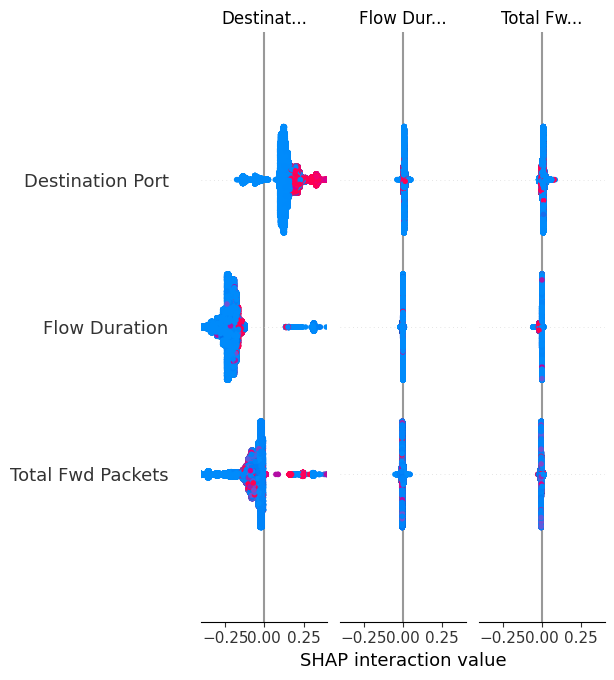

In [13]:
shap.summary_plot(
    shap_values,
    X_test,
    class_names=class_names
)


# Bar Plot Importance

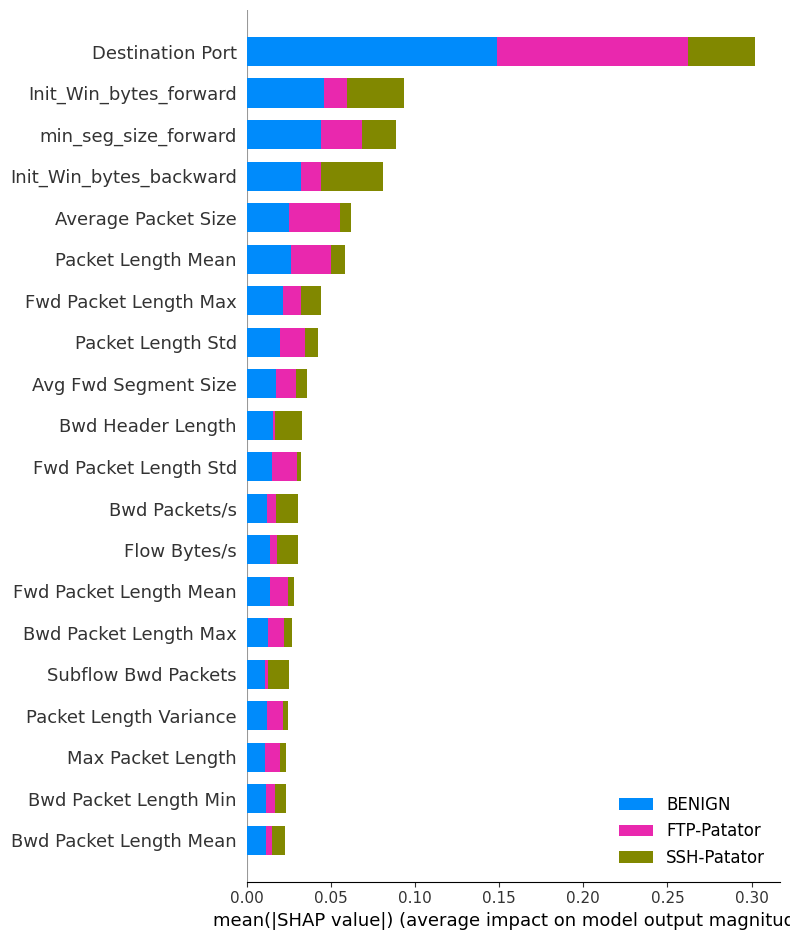

In [14]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    class_names=class_names
)


# One Specific Prediction Explanation

In [15]:
sample_index = 25

sample = X_test.iloc[sample_index]

prediction = model.predict(sample.to_frame().T)[0]

print("Predicted class:", int_to_label[prediction])

print("\nActual class:", int_to_label[y_test.iloc[sample_index]])


Predicted class: BENIGN

Actual class: BENIGN


# waterfall Plot

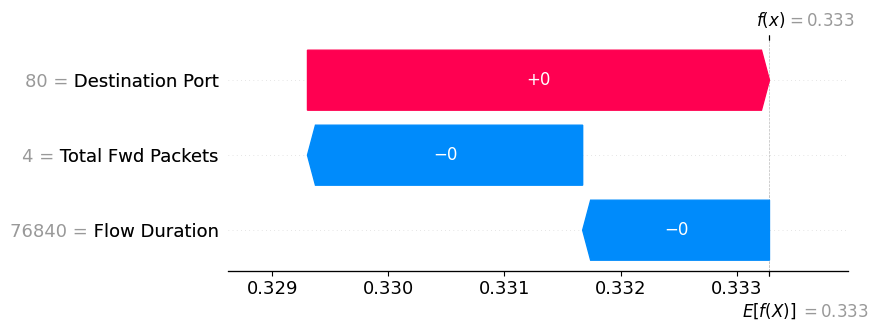

In [16]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[prediction][sample_index],
        base_values=explainer.expected_value[prediction],
        data=sample.values,
        feature_names=X_test.columns.tolist()
    )
)


# Top feature importance table

In [20]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importances.head(15)

print(top_features)


Destination Port           0.168376
Init_Win_bytes_backward    0.078814
Init_Win_bytes_forward     0.052019
Packet Length Mean         0.048274
Average Packet Size        0.037874
min_seg_size_forward       0.036565
Fwd Packet Length Max      0.033037
Flow Bytes/s               0.028418
Fwd Packet Length Mean     0.026968
Bwd Packets/s              0.026627
Fwd Packet Length Std      0.025575
Packet Length Std          0.025482
Avg Fwd Segment Size       0.024070
Fwd Header Length          0.023755
Packet Length Variance     0.022480
dtype: float64


# Plot top features

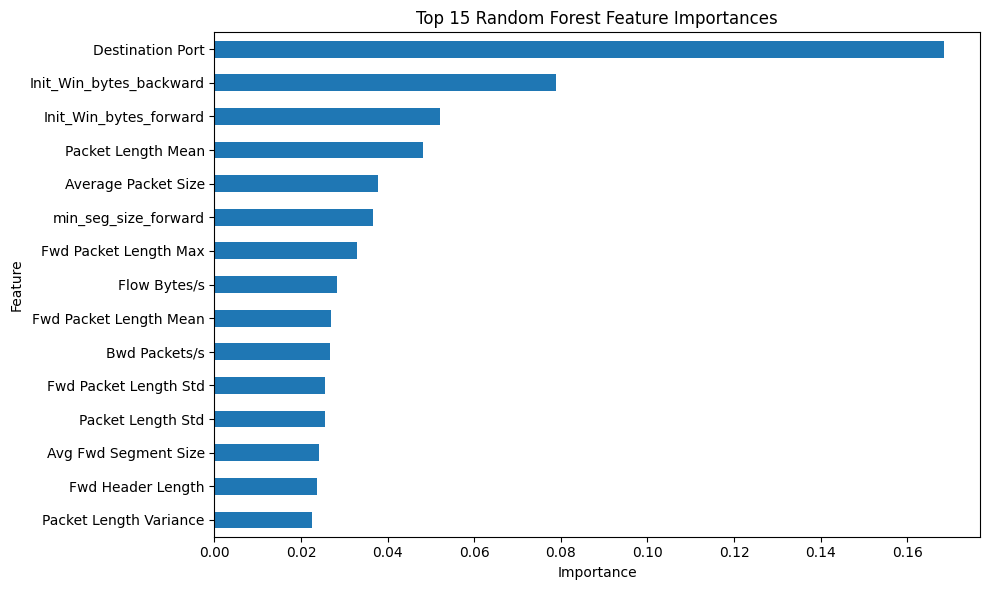

In [21]:
top_features.sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()
